> ✍️ **My Work** 



### 1. Library Imports & Environment Setup

First, I am importing the essential PyTorch libraries and torchvision for handling the MNIST dataset. I also bring in `matplotlib` for any visualizations and `tqdm` for tracking the training progress.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader
import torchvision.datasets as ds
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.datasets as ds


> ✍️ **My Work**



### 2. Loading the MNIST Dataset

Here, I'm downloading the standard MNIST dataset. I apply `transforms.ToTensor()` so that the pixel values are nicely scaled between 0 and 1. I then wrap it in a `DataLoader` to feed my model in batches of 64.


In [ ]:

transform = transforms.ToTensor()

dataset = ds.MNIST(root="./data", train=True, download=True, transform=transform)

batch_size = 64
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

for inputs, targets in dataloader:
    print(inputs.shape)
    print(targets.shape)
    break


100%|██████████| 9.91M/9.91M [05:11<00:00, 31.8kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 162kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.60MB/s]

torch.Size([64, 1, 28, 28])
torch.Size([64])


> ✍️ **My Work**



### 3. The VAE Architecture & Reparameterization Trick

This is the core architecture I built. It consists of:

- **Encoder:** An MLP that compresses the 784-dimensional image into 256 dimensions.

- **Chunking:** I split those 256 dimensions equally into `mu` (means) and `log_vars` (log-variances) for our 128-dimensional latent space.

- **Reparameterization Trick:** Instead of sampling directly (which breaks gradients), I sample random `eps` and shift/scale it using `mu` and `sigma`.

- **Decoder:** Another MLP that takes the 128D latent vector and expands it back to 784 pixels, ending with a `Sigmoid` to ensure the output is exactly between 0 and 1.


In [9]:
class VAE(nn.Module):
    def __init__(self, d_in = 784, z = 128 ):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4,  2*z),
        )
        self.decoder = nn.Sequential(
            nn.Linear(z, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4, d_in),
            nn.Sigmoid()

        )

        self.d_in = d_in
        self.z = z


    def encode(self, x):
        return self.encoder(x)
    def decode(self, x):
        return self.decoder(x)
    def forward(self, x):
        x_encoded = self.encode(x)
        meus, log_vars = torch.chunk(x_encoded, 2 , dim =-1)
        sigmas = torch.exp(0.5* log_vars)
        eps = torch.randn_like(sigmas)
        z = meus + eps * sigmas
        return self.decoder(z), meus, sigmas, log_vars

> ✍️ **My Work**



### 4. Testing the Forward Pass

A quick sanity check to ensure the model architecture is solid. I pass a dummy batch of random noise through the VAE and confirm that it outputs the expected `x_hat`, `meus`, `sigmas`, and `log_vars`.


In [5]:
x = torch.randn(size = (12, 784)).to("cuda")
model = VAE().to("cuda")
x_hat, meus, sigmas, log_vars = model(x)



> ✍️ **My Work**



### 5. Optimizer Initialization

Setting up the AdamW optimizer with a learning rate of `5e-5` to update the model weights.


In [6]:
optimizer = torch.optim.AdamW(params = model.parameters() , lr =5e-5)

> ✍️ **My Work**



### 6. The Training Loop & ELBO Loss

This is where the magic happens. For every batch, I calculate the **Evidence Lower Bound (ELBO)**:

- **Reconstruction Loss (MSE):** How well does the output match the input? 
- **KL Divergence:** How close is the latent space to a Standard Normal distribution?



*Note on Training:* This model is **slightly undertrained** in this specific run.  But it serves as a great artifact for our noise study below!


In [8]:

EPOCHS = 100

for i in tqdm(range(EPOCHS)):
    total_loss = 0
    model.train()
    for x, _ in dataloader:
        x = x.flatten(1).to("cuda")
        x_hat, meus, sigmas, log_vars = model(x)

        kl_loss = - 0.5 * (1+log_vars - meus**2 -sigmas**2 ).sum(dim =-1).mean(dim = 0)
        recon_loss = F.mse_loss(x_hat, x, reduction ="none").sum(dim = -1).mean(dim = 0)
        loss = recon_loss + kl_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    print(f"Epoch {i+1} | Average Loss: {avg_loss:.4f}")
    print(f"Samples covered: {len(dataloader)}")



  1%|          | 1/100 [00:18<00:00, 17.50s/it]

Epoch 1 | Average Loss: 42.3117
Samples covered: 938


  2%|          | 2/100 [00:18<00:00, 17.50s/it]

Epoch 2 | Average Loss: 37.6221
Samples covered: 938


  3%|          | 3/100 [00:18<00:00, 17.50s/it]

...

Epoch 98 | Average Loss: 24.5189
Samples covered: 938


 99%|█████████ | 99/100 [00:18<00:00, 17.50s/it]

Epoch 99 | Average Loss: 24.5033
Samples covered: 938


100%|██████████| 100/100 [00:18<00:00, 17.50s/it]

Epoch 100 | Average Loss: 24.4882
Samples covered: 938


In [ ]:

def show_tensor_image(tensor_img):
    # 1. Pull tensor from GPU memory and detach from the computation graph
    img = tensor_img.detach().cpu()

    # 2. CASE A: If you used transforms.Normalize((0.5,), (0.5,)) during loading,
    # un-normalize back to [0, 1] by multiplying by std and adding mean:
    # img = img * 0.5 + 0.5

    # 3. CASE B: If your decoder ends with a Sigmoid activation, clamp to [0, 1] safety boundary
    img = torch.clamp(img, 0.0, 1.0)

    # 4. Reshape back from a flattened vector (e.g., 784) to an image shape (e.g., 28x28)
    # If using RGB data, use (3, 28, 28)
    img = img.view(28, 28)

    # 5. Plot using matplotlib
    plt.imshow(img.numpy(), cmap="gray")
    plt.axis("off")
    plt.show()




In [ ]:

def show_noise_image(tensor_img):
    # 1. Pull tensor from GPU memory and detach from the computation graph
    img = tensor_img.detach().cpu()

    # 2. CASE A: If you used transforms.Normalize((0.5,), (0.5,)) during loading,
    # un-normalize back to [0, 1] by multiplying by std and adding mean:
    # img = img * 0.5 + 0.5

    # 3. CASE B: If your decoder ends with a Sigmoid activation, clamp to [0, 1] safety boundary
    img = torch.clamp(img, 0.0, 1.0)

    # 4. Reshape back from a flattened vector (e.g., 784) to an image shape (e.g., 28x28)
    # If using RGB data, use (3, 28, 28)
    img = img.view(16 , 8)

    # 5. Plot using matplotlib
    plt.imshow(img.numpy(), cmap="gray")
    plt.axis("off")
    plt.show()




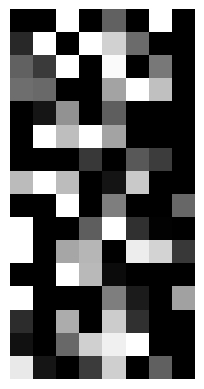

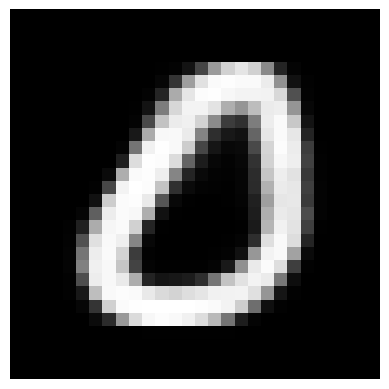

In [ ]:
z = torch.randn(128).to("cuda")
show_noise_image(z)
model.eval()
show_tensor_image(model.decode(z))




In [ ]:
#torch.save(model.state_dict(), 'VAE_MNIST.pt')

In [ ]:
# 1. Initialize your model architecture
model = VAE().to("mps")

# 2. Load the state dictionary from disk
state_dict = torch.load('VAE_MNIST.pt', weights_only=True, map_location=torch.device('mps'))

# 3. Flash the weights into your model
model.load_state_dict(state_dict)

# 4. ALWAYS set to evaluation mode if you are running inference
model.eval() 


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=3136, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=3136, out_features=3136, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=3136, out_features=256, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=3136, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=3136, out_features=3136, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=3136, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

---

> 🤖 **AI-Assisted** — Noise Distribution Study

In this study, we use UMAP to classify generated images back into digit clusters. We then average the random noise (`eps`) that generated each digit to see if specific latent dimensions are responsible for specific digits.

> 🤖 **AI-Assisted**



### 7. Noise Distribution Study: UMAP Projection

*The experiment concept was mine, but the specific implementation for UMAP and visualization was written by AI.*



To understand how the VAE maps concepts, we first take all 60,000 training images and encode them into the 128-dimensional latent space. We then use UMAP to project this 128D space down to 2D so we can find the central cluster (centroid) for each digit from 0 to 9.


In [ ]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min

# 1. Extract latent representations (z) for the 60k training images
model.eval()
z_train = []
y_train = []
dev = "mps"
model.to(dev)

with torch.no_grad():
    for x, y in tqdm(dataloader, desc="Encoding Train Set"):
        x = x.flatten(1).to(dev)
        # encode
        x_encoded = model.encode(x)
        meus, log_vars = torch.chunk(x_encoded, 2, dim=-1)
        # Use the mean (meus) as the representative latent vector z for training data
        z_train.append(meus.cpu().numpy())
        y_train.append(y.numpy())

z_train = np.concatenate(z_train, axis=0)
y_train = np.concatenate(y_train, axis=0)
print(f"Extracted {z_train.shape[0]} latent vectors.")

Encoding Train Set: 100%|██████████| 938/938 [00:02<00:00, 346.78it/s]

Extracted 60000 latent vectors.


Fitting UMAP (this might take a minute)...


/Users/abdullah/Pytorch/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


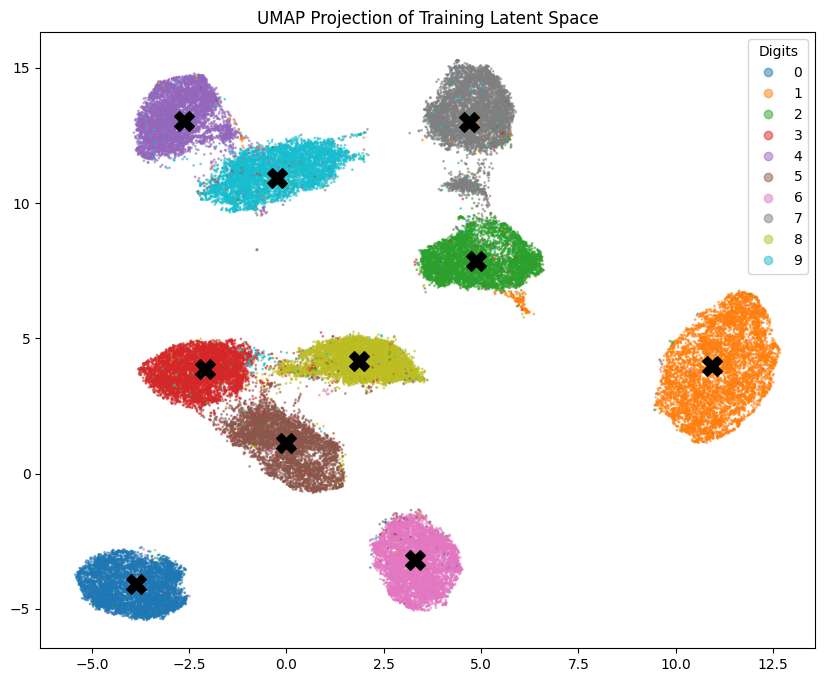

In [ ]:
# 2. Fit UMAP on the training latent space and find centroids
print("Fitting UMAP (this might take a minute)...")
reducer = umap.UMAP(random_state=42)
umap_train = reducer.fit_transform(z_train)

centroids = []
for i in range(10):
    mask = (y_train == i)
    centroid = umap_train[mask].mean(axis=0)
    centroids.append(centroid)

centroids = np.array(centroids)

# Plot the UMAP clusters and centroids
plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_train[:, 0], umap_train[:, 1], c=y_train, cmap="tab10", s=1, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label="Centroids")
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("UMAP Projection of Training Latent Space")
plt.show()

> 🤖 **AI-Assisted**



### 7.1 Classifying Random Noise Vectors

Now we generate 10,000 pure random noise vectors `eps`. We pass them through the decoder to see what images they generate, and then immediately re-encode those images back into the latent space. 



By mapping these new latent vectors into our UMAP space, we can classify which specific digit each random noise vector was responsible for generating!


In [ ]:
# 3. Generate random noise, decode, re-encode, and classify
N_SAMPLES = 10000
dev = "cuda" if torch.cuda.is_available() else "cpu"
model.to(dev)

# Generate random noise eps ~ N(0, I)
eps_samples = torch.randn(N_SAMPLES, model.z).to(dev)

with torch.no_grad():
    # Standard VAE decoding expects z = mu + eps * sigma. 
    # For pure generation, we set mu=0, sigma=1, so z = eps.
    generated_images = model.decode(eps_samples)
    
    # Re-encode to find where these generated images land in the latent space
    encoded_gen = model.encode(generated_images)
    meus_gen, _ = torch.chunk(encoded_gen, 2, dim=-1)
    z_gen = meus_gen.cpu().numpy()

# Map the generated latents to the same 2D UMAP space
print("Projecting generated images to UMAP space...")
umap_gen = reducer.transform(z_gen)

# Classify by finding the closest centroid
closest_centroid_indices, _ = pairwise_distances_argmin_min(umap_gen, centroids)
predicted_digits = closest_centroid_indices

Projecting generated images to UMAP space...


> 🤖 **AI-Assisted**



### 7.2 The Heatmap: Average Noise per Digit

Here, we group the 10,000 noise vectors by the digit they generated. We then calculate the **mean vector** for each digit class and plot it as a heatmap.



This reveals the distinct 'directional wedges' the VAE has carved out in the Gaussian prior. Certain dimensions light up strongly for specific digits, showing how the model learned to disentangle features!


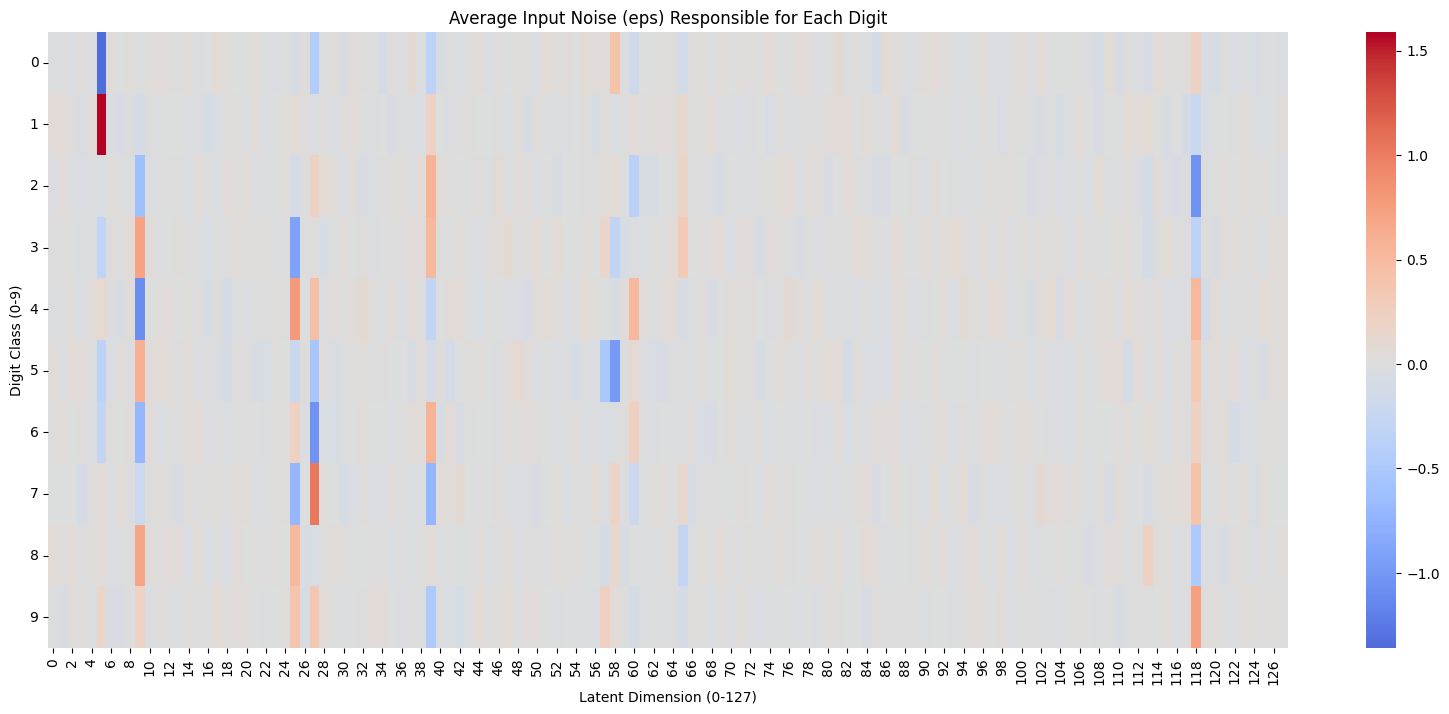

In [ ]:
# 4. Calculate average noise per digit and plot heatmap
avg_noise_per_digit = np.zeros((10, model.z))
eps_np = eps_samples.cpu().numpy()

for i in range(10):
    mask = (predicted_digits == i)
    if mask.sum() > 0:
        avg_noise_per_digit[i] = eps_np[mask].mean(axis=0)

plt.figure(figsize=(20, 8))
sns.heatmap(avg_noise_per_digit, cmap="coolwarm", center=0)
plt.title("Average Input Noise (eps) Responsible for Each Digit")
plt.xlabel("Latent Dimension (0-127)")
plt.ylabel("Digit Class (0-9)")
plt.yticks(rotation=0)
plt.show()

> 🤖 **AI-Assisted**



### 8. Generating Platonic Prototypes from Average Noise

*The overarching idea to explore this was mine, but the code to visualize the tensors was generated by AI.*



Since we found the average random noise vectors that correspond to specific digits, we can pass these 'average' vectors back into the decoder. Because all random stylistic variations cancel out, the decoder generates the perfect, archetypal 'Platonic' representation of each digit.


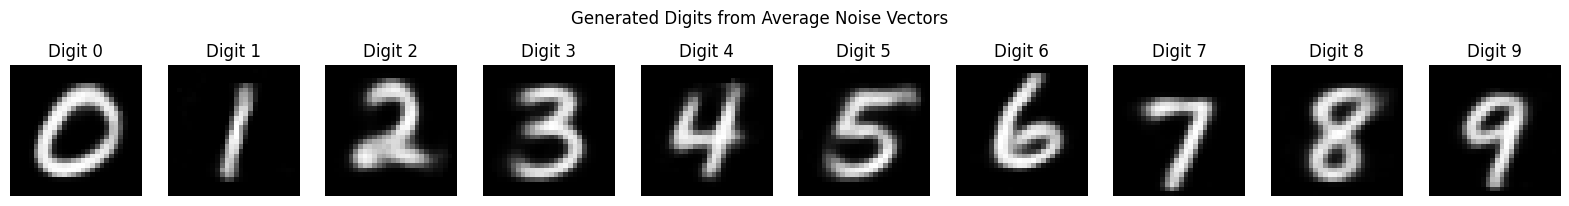

In [20]:
# Convert the average noise numpy array back to a PyTorch tensor
target_noise = torch.tensor(avg_noise_per_digit, dtype=torch.float32).to(dev)

# Generate images from these 10 average noise vectors
with torch.no_grad():
    generated_prototypes = model.decode(target_noise).cpu()

# Plot the 10 "prototype" digits
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    # Reshape from flat 784 back to 28x28 image
    img = generated_prototypes[i].view(28, 28).numpy()
    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Digit {i}")

plt.suptitle("Generated Digits from Average Noise Vectors", y=1.1)
plt.show()
